# 04 — Результаты стратегии

Аналитика финальной стратегии на walk-forward результатах: ROI по сезонам, bankroll-симуляция, ablation Pinnacle, распределение эджа, сравнение стратегий, итог.

Рынок в бэктесте — закрывающая линия Pinnacle (96% ставок) / Betfair (4%), не Polymarket (см. README_RU.md). Числа берутся как есть из walkforward_results.parquet.

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.metrics import brier_score_loss
from sklearn.calibration import calibration_curve
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
})

HOLDOUT_YEAR = 2019  # selection: <2019, holdout: >=2019

In [2]:
features = pd.read_parquet('../data/processed/football_features.parquet')
results  = pd.read_parquet('../data/results/walkforward_results.parquet')
results_np = pd.read_parquet('../data/results/walkforward_results_no_pinnacle.parquet')
fi_with    = pd.read_csv('../data/results/feature_importance_full.csv', index_col=0).squeeze()
fi_without = pd.read_csv('../data/results/feature_importance_no_pinnacle.csv', index_col=0).squeeze()

results['Date'] = pd.to_datetime(results['Date'])
results['year'] = results['Season'].str[:4].astype(int)
results_np['year'] = results_np['Season'].str[:4].astype(int)

print(f'Матчей: {len(features):,}  |  Лиг: {features["League"].nunique()}  |  Сезонов: {features["Season"].nunique()}')
print(f'Строк walk-forward: {len(results):,}')
print(f'Период: {results["Date"].min().date()} — {results["Date"].max().date()}')

Матчей: 94,043  |  Лиг: 12  |  Сезонов: 26
Строк walk-forward: 73,469
Период: 2006-08-26 — 2026-03-22


## 1. ROI по сезонам — Примейра, home+draw, edge ≥ 0.18

Holdout: 2019–2026. На selection-периоде (2006–2018) стратегия отбиралась, holdout трогали один раз. Всего в плюс 13 сезонов из 18.

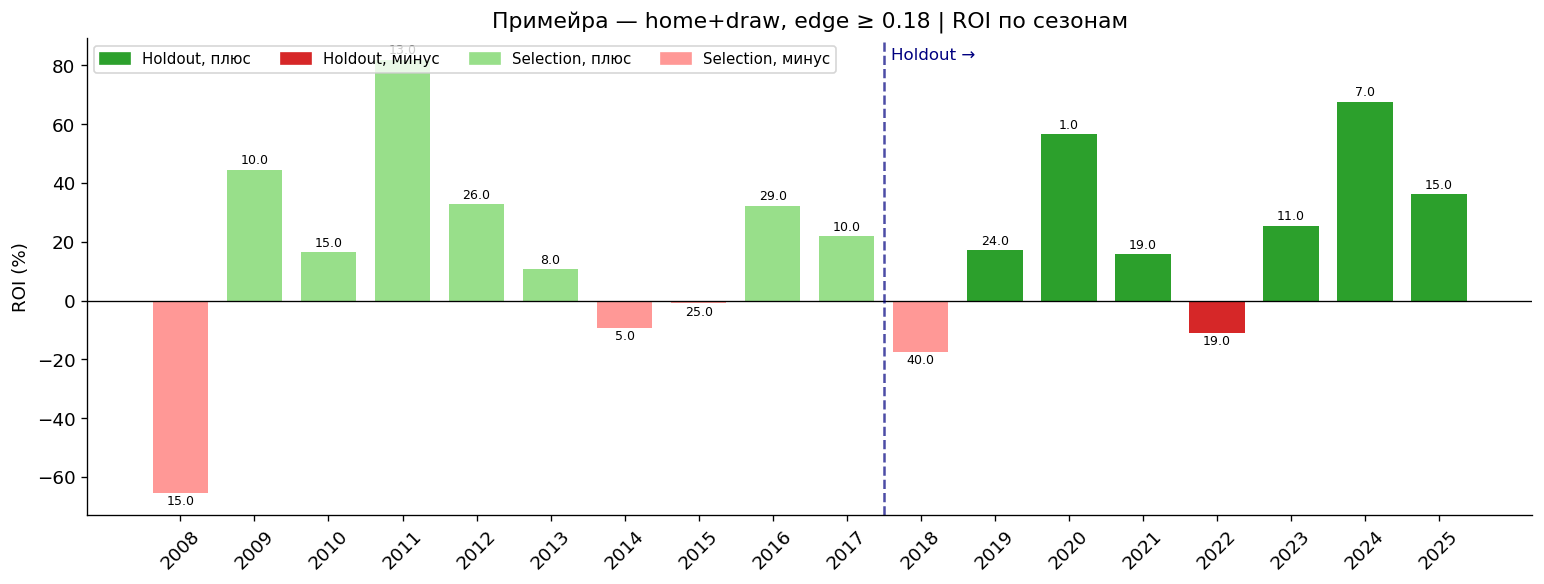

Selection (2006–2018): ROI=+10.1%, 7/11 positive seasons
Holdout   (2019–2026): ROI=+19.6%, 6/7 positive seasons


In [3]:
p1_bets = results[
    (results['League'] == 'P1') &
    (results['best_outcome'].isin(['home', 'draw'])) &
    (results['best_edge'] >= 0.18) &
    (results['kelly_size'] > 0)
].copy()

season_stats = p1_bets.groupby('Season').agg(
    n_bets   = ('profit', 'count'),
    profit   = ('profit', 'sum'),
    staked   = ('kelly_size', 'sum'),
    year     = ('year', 'first'),
).assign(roi=lambda d: d['profit'] / d['staked'])

fig, ax = plt.subplots(figsize=(13, 5))

colors = ['#2ca02c' if (r > 0 and y >= HOLDOUT_YEAR) else
          '#98df8a' if (r > 0 and y < HOLDOUT_YEAR) else
          '#d62728' if (r <= 0 and y >= HOLDOUT_YEAR) else
          '#ff9896'
          for r, y in zip(season_stats['roi'], season_stats['year'])]

x = range(len(season_stats))
bars = ax.bar(x, season_stats['roi'] * 100, color=colors, width=0.75)
ax.axhline(0, color='black', linewidth=0.8)
ax.axvline(season_stats.index.tolist().index('2018/2019') - 0.5,
           color='navy', linewidth=1.5, linestyle='--', alpha=0.7)
ax.text(season_stats.index.tolist().index('2018/2019') - 0.5 + 0.1, ax.get_ylim()[1] * 0.92,
        'Holdout →', color='navy', fontsize=10)

ax.set_xticks(x)
ax.set_xticklabels([s[:4] for s in season_stats.index], rotation=45)
ax.set_ylabel('ROI (%)')
ax.set_title('Примейра — home+draw, edge ≥ 0.18 | ROI по сезонам')

from matplotlib.patches import Patch
legend_els = [
    Patch(color='#2ca02c', label='Holdout, плюс'),
    Patch(color='#d62728', label='Holdout, минус'),
    Patch(color='#98df8a', label='Selection, плюс'),
    Patch(color='#ff9896', label='Selection, минус'),
]
ax.legend(handles=legend_els, ncol=4, fontsize=9, loc='upper left')

for i, (s, row) in enumerate(season_stats.iterrows()):
    ax.text(i, row['roi'] * 100 + (2 if row['roi'] >= 0 else -4),
            f"{row['n_bets']}", ha='center', fontsize=7.5, color='black')

plt.tight_layout()
plt.savefig("../results/figures/roi_by_season.png", dpi=150, bbox_inches="tight")
plt.show()

sel = season_stats[season_stats['year'] < HOLDOUT_YEAR]
hld = season_stats[season_stats['year'] >= HOLDOUT_YEAR]
print(f'Selection (2006–2018): ROI={sel["profit"].sum()/sel["staked"].sum():+.1%}, '
      f'{(sel["roi"]>0).sum()}/{len(sel)} positive seasons')
print(f'Holdout   (2019–2026): ROI={hld["profit"].sum()/hld["staked"].sum():+.1%}, '
      f'{(hld["roi"]>0).sum()}/{len(hld)} positive seasons')

## 2. Симуляция банкролла — динамический Kelly

Quarter-Kelly с капом 10% банка на ставку. Старт $1,000, 292 ставки за 18 сезонов, финал $1,699 (+70%), максимальная просадка −11.9%.

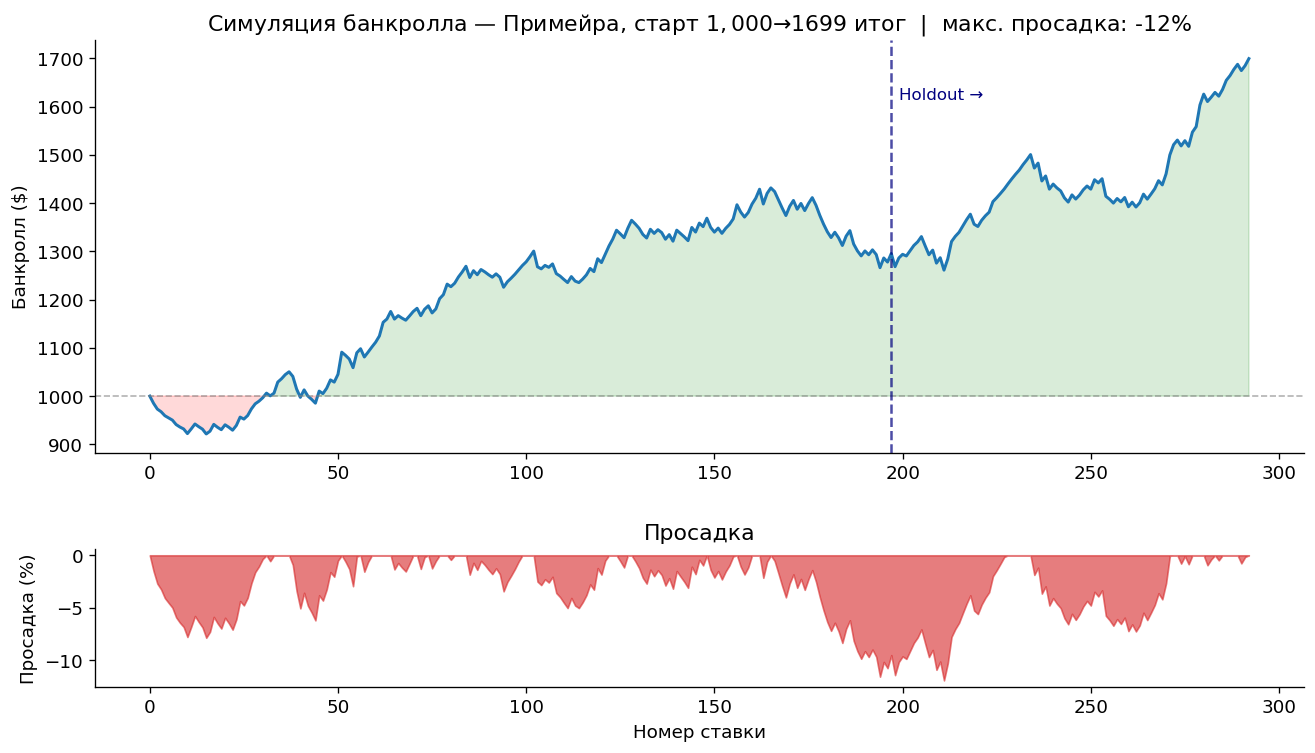

Итоговый банкролл: $1699  (+70%)
Макс. просадка:  -11.9%
Всего ставок:    292
Ставок в сезон:  16.2


In [4]:
p1_bets_sorted = p1_bets.sort_values('Date').copy()

START = 1000.0
bankroll = START
history = [bankroll]
dates   = [p1_bets_sorted['Date'].iloc[0]]

for _, row in p1_bets_sorted.iterrows():
    stake = min(row['kelly_size'] * bankroll, bankroll * 0.10)
    bankroll += row['profit'] * stake
    bankroll = max(bankroll, 1.0)
    history.append(bankroll)
    dates.append(row['Date'])

history = np.array(history)
running_max = np.maximum.accumulate(history)
drawdown = (history - running_max) / running_max * 100

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 7), sharex=False,
                                gridspec_kw={'height_ratios': [3, 1], 'hspace': 0.35})

ax1.plot(range(len(history)), history, color='#1f77b4', linewidth=1.8)
ax1.axhline(START, color='gray', linestyle='--', linewidth=1, alpha=0.6)

holdout_start = (p1_bets_sorted['year'] >= HOLDOUT_YEAR).idxmax()
holdout_idx = p1_bets_sorted.index.get_loc(holdout_start) + 1
ax1.axvline(holdout_idx, color='navy', linestyle='--', linewidth=1.5, alpha=0.7)
ax1.text(holdout_idx + 2, max(history) * 0.95, 'Holdout →', color='navy', fontsize=10)

ax1.fill_between(range(len(history)), START, history,
                 where=np.array(history) > START, alpha=0.15, color='green')
ax1.fill_between(range(len(history)), START, history,
                 where=np.array(history) <= START, alpha=0.15, color='red')

ax1.set_ylabel('Банкролл ($)')
ax1.set_title(f'Симуляция банкролла — Примейра, старт $1,000'
              f' → ${bankroll:.0f} итог  |  макс. просадка: {drawdown.min():.0f}%')

ax2.fill_between(range(len(drawdown)), drawdown, 0, color='#d62728', alpha=0.6)
ax2.set_ylabel('Просадка (%)')
ax2.set_xlabel('Номер ставки')
ax2.set_title('Просадка')

plt.tight_layout()
plt.show()

print(f'Итоговый банкролл: ${bankroll:.0f}  ({(bankroll/START - 1)*100:+.0f}%)')
print(f'Макс. просадка:  {drawdown.min():.1f}%')
print(f'Всего ставок:    {len(p1_bets_sorted)}')
print(f'Ставок в сезон:  {len(p1_bets_sorted)/season_stats["year"].nunique():.1f}')

## 3. Ablation Pinnacle — проверка на замкнутость

Implied-вероятности Pinnacle входят в фичи модели, а он же выступает рынком в бэктесте. Возникает петля: модель может просто воспроизводить Pinnacle вместо поиска независимого сигнала. Feature importance показывает **~32% всего split gain** на Pinnacle-колонках.

Прогнал весь пайплайн заново с полностью убранными Pinnacle-колонками: та же архитектура, тот же бюджет Optuna, те же walk-forward фолды. Меняется ровно одно.

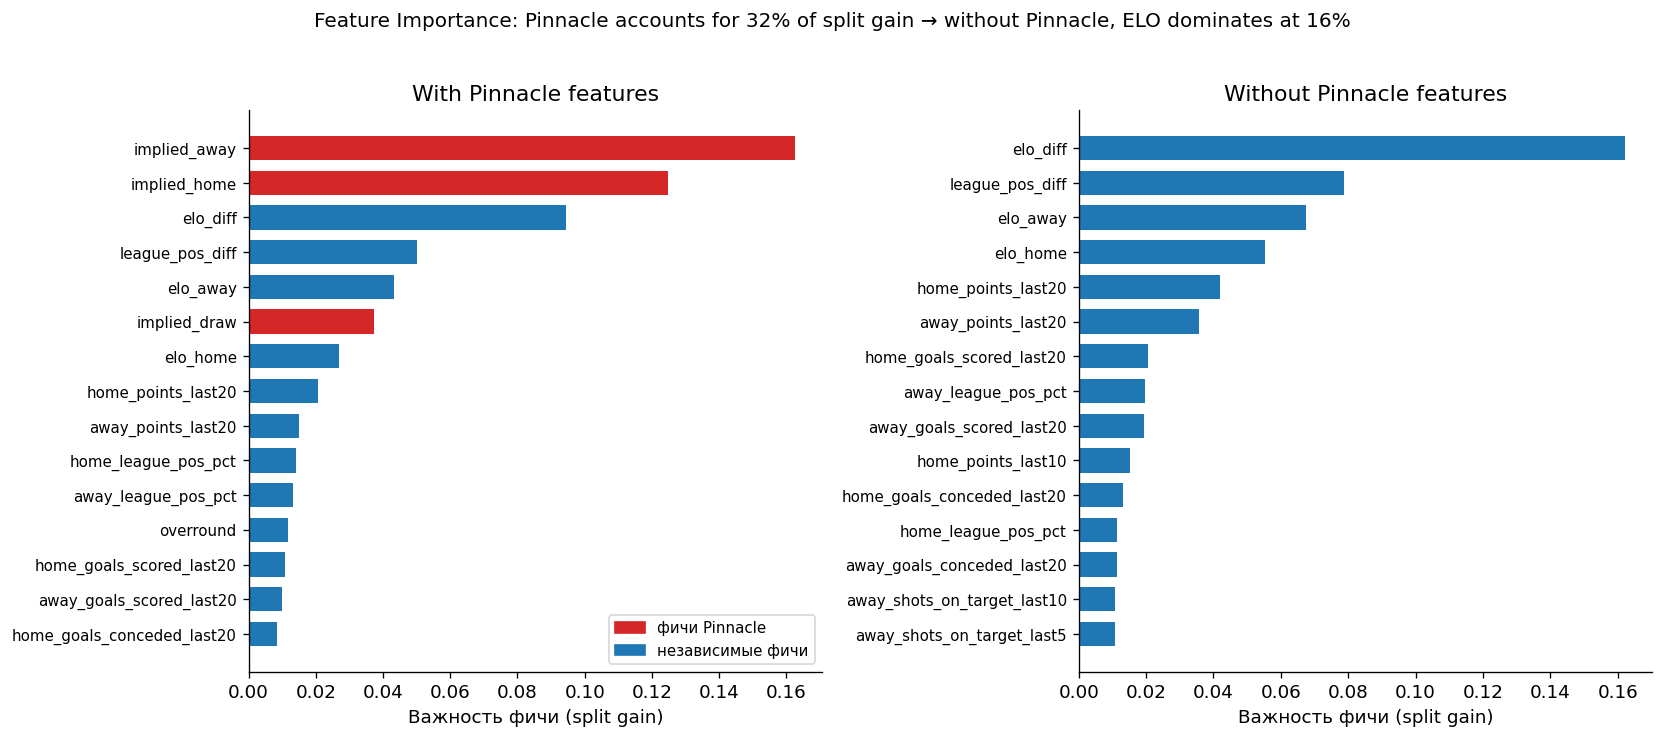

Суммарная важность Pinnacle: 32.5%
Без Pinnacle топ-фича: elo_diff (16.2%)


In [5]:
TOP_N = 15
PINNACLE_COLS = {'implied_home', 'implied_draw', 'implied_away'}

top_with    = fi_with.head(TOP_N)
top_without = fi_without.head(TOP_N)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, fi, title in [
    (axes[0], top_with,    'With Pinnacle features'),
    (axes[1], top_without, 'Without Pinnacle features'),
]:
    colors = ['#d62728' if idx in PINNACLE_COLS else '#1f77b4' for idx in fi.index]
    ax.barh(range(len(fi)), fi.values, color=colors, height=0.7)
    ax.set_yticks(range(len(fi)))
    ax.set_yticklabels(fi.index, fontsize=9)
    ax.invert_yaxis()
    ax.set_xlabel('Важность фичи (split gain)')
    ax.set_title(title)

from matplotlib.patches import Patch
axes[0].legend(handles=[
    Patch(color='#d62728', label='фичи Pinnacle'),
    Patch(color='#1f77b4', label='независимые фичи'),
], fontsize=9)

pinnacle_sum = fi_with[list(PINNACLE_COLS)].sum()
fig.suptitle(f'Feature Importance: Pinnacle accounts for {pinnacle_sum:.0%} of split gain '
             f'→ without Pinnacle, ELO dominates at {fi_without.iloc[0]:.0%}',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig("../results/figures/feature_importance_ablation.png", dpi=150, bbox_inches="tight")
plt.show()

print(f'Суммарная важность Pinnacle: {pinnacle_sum:.1%}')
print(f'Без Pinnacle топ-фича: {fi_without.index[0]} ({fi_without.iloc[0]:.1%})')

## 4. Распределение эджа — где модель видит мисprice

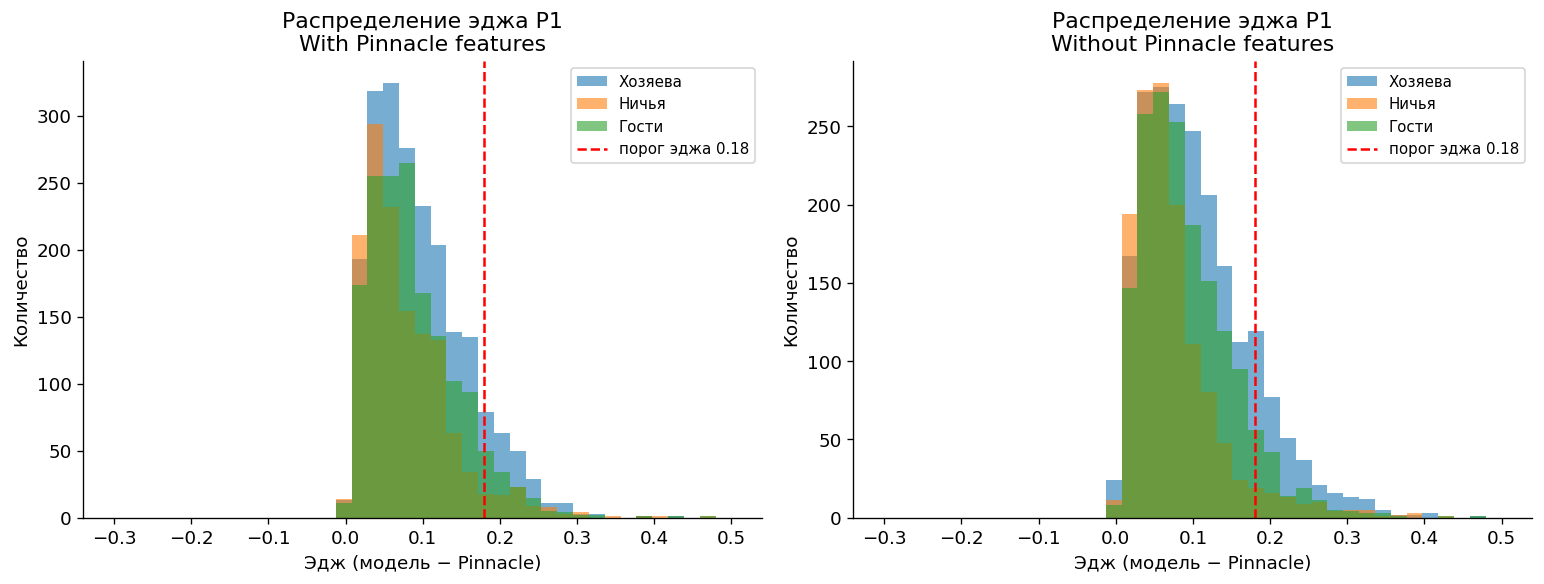

Ставки P1 с эджем ≥ 0.18:
  home   с Pinnacle: 213  |  без: 300
  draw   с Pinnacle:  79  |  без:  79
  away   с Pinnacle: 114  |  без: 138


In [6]:
# эдж = вероятность модели минус implied Pinnacle, по всем матчам P1
p1_all = results[results['League'] == 'P1'].dropna(subset=['best_edge', 'best_outcome'])
p1_all_np = results_np[results_np['League'] == 'P1'].dropna(subset=['best_edge', 'best_outcome'])

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, data, label, color in [
    (axes[0], p1_all,    'With Pinnacle features',    '#1f77b4'),
    (axes[1], p1_all_np, 'Without Pinnacle features', '#2ca02c'),
]:
    home_edge = data[data['best_outcome'] == 'home']['best_edge']
    draw_edge = data[data['best_outcome'] == 'draw']['best_edge']
    away_edge = data[data['best_outcome'] == 'away']['best_edge']

    bins = np.linspace(-0.3, 0.5, 40)
    ax.hist(home_edge, bins=bins, alpha=0.6, label='Хозяева', color='#1f77b4')
    ax.hist(draw_edge, bins=bins, alpha=0.6, label='Ничья', color='#ff7f0e')
    ax.hist(away_edge, bins=bins, alpha=0.6, label='Гости', color='#2ca02c')
    ax.axvline(0.18, color='red', linestyle='--', linewidth=1.5, label='порог эджа 0.18')
    ax.set_xlabel('Эдж (модель − Pinnacle)')
    ax.set_ylabel('Количество')
    ax.set_title(f'Распределение эджа P1\n{label}')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

print('Ставки P1 с эджем ≥ 0.18:')
for outcome in ['home', 'draw', 'away']:
    n_with = ((p1_all['best_outcome'] == outcome) & (p1_all['best_edge'] >= 0.18)).sum()
    n_wo   = ((p1_all_np['best_outcome'] == outcome) & (p1_all_np['best_edge'] >= 0.18)).sum()
    print(f'  {outcome:<5}  с Pinnacle: {n_with:>3}  |  без: {n_wo:>3}')

## 5. Сравнение стратегий

Grid search по ~500 комбинациям на selection (2006–2018), проверка на holdout (2019–2026). Большинство стратегий разваливается на holdout — эффект множественных сравнений. Защита здесь именно в честном сплите selection/holdout, а не в скорректированном Sharpe.

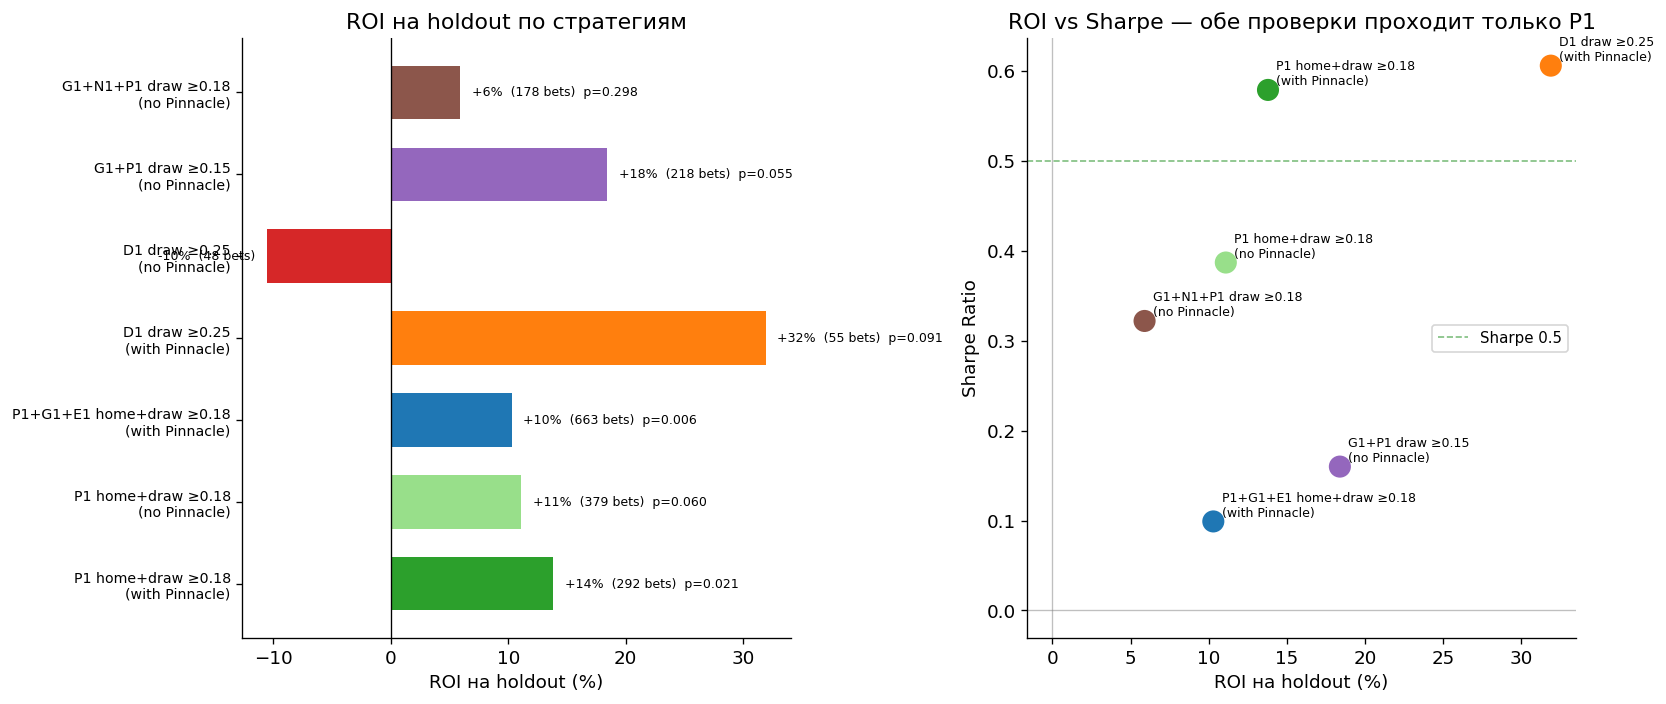

In [7]:
LEAGUE_NAMES = {
    'P1': 'Primeira Liga (Portugal)',
    'D1': 'Bundesliga (Germany)',
    'G1': 'Super League (Greece)',
    'E1': 'Championship (England)',
    'N1': 'Eredivisie (Netherlands)',
    'E0': 'Premier League (England)',
    'SP1': 'La Liga (Spain)',
}

strategies = [
    # метка, roi, sharpe, число ставок, p-value, маркер
    ('P1 home+draw ≥0.18\n(with Pinnacle)',          0.138, 0.579, 292, 0.021, 'star',   '#2ca02c'),
    ('P1 home+draw ≥0.18\n(no Pinnacle)',             0.111, 0.387, 379, 0.060, 'circle', '#98df8a'),
    ('P1+G1+E1 home+draw ≥0.18\n(with Pinnacle)',     0.103, 0.099, 663, 0.006, 'circle', '#1f77b4'),
    ('D1 draw ≥0.25\n(with Pinnacle)',                0.319, 0.606,  55, 0.091, 'circle', '#ff7f0e'),
    ('D1 draw ≥0.25\n(no Pinnacle)',                 -0.105, None,   48, None,  'circle', '#d62728'),
    ('G1+P1 draw ≥0.15\n(no Pinnacle)',               0.184, 0.160, 218, 0.055, 'circle', '#9467bd'),
    ('G1+N1+P1 draw ≥0.18\n(no Pinnacle)',            0.059, 0.322, 178, 0.298, 'circle', '#8c564b'),
]

labels = [s[0] for s in strategies]
rois   = [s[1] * 100 for s in strategies]
sharpes = [s[2] if s[2] is not None else 0 for s in strategies]
n_bets = [s[3] for s in strategies]
pvals  = [s[4] for s in strategies]
colors = [s[6] for s in strategies]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# столбики ROI
x = range(len(strategies))
axes[0].barh(x, rois, color=colors, height=0.65)
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].set_yticks(x)
axes[0].set_yticklabels(labels, fontsize=8.5)
axes[0].set_xlabel('ROI на holdout (%)')
axes[0].set_title('ROI на holdout по стратегиям')
for i, (roi, nb, pv) in enumerate(zip(rois, n_bets, pvals)):
    txt = f'{roi:+.0f}%  ({nb} bets)'
    if pv is not None:
        txt += f'  p={pv:.3f}'
    axes[0].text(roi + (1 if roi >= 0 else -1), i, txt,
                va='center', ha='left' if roi >= 0 else 'right', fontsize=7.5)

# скаттер по Sharpe
valid_idx = [i for i, s in enumerate(strategies) if s[2] is not None]
axes[1].scatter([rois[i] for i in valid_idx], [sharpes[i] for i in valid_idx],
               c=[colors[i] for i in valid_idx], s=150, zorder=3)
axes[1].axvline(0, color='gray', linewidth=0.8, alpha=0.5)
axes[1].axhline(0, color='gray', linewidth=0.8, alpha=0.5)
axes[1].axhline(0.5, color='green', linestyle='--', linewidth=1, alpha=0.5, label='Sharpe 0.5')
for i in valid_idx:
    axes[1].annotate(labels[i], (rois[i], sharpes[i]),
                    textcoords='offset points', xytext=(5, 3), fontsize=7.5)
axes[1].set_xlabel('ROI на holdout (%)')
axes[1].set_ylabel('Sharpe Ratio')
axes[1].set_title('ROI vs Sharpe — обе проверки проходит только P1')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

## 6. Итог по финальной стратегии

In [8]:
from scipy import stats

p1_holdout = p1_bets[p1_bets['year'] >= HOLDOUT_YEAR].copy()
p1_all_seasons = p1_bets.copy()

# доля побед против той, что заложена в цене рынка
win_rate = (p1_holdout['profit'] > 0).mean()
mkt_win_rate = p1_holdout.apply(
    lambda r: r['market_home'] if r['best_outcome'] == 'home' else r['market_draw'], axis=1
).mean()

# биномиальный тест
n_wins = (p1_holdout['profit'] > 0).sum()
binom = stats.binomtest(n_wins, len(p1_holdout), mkt_win_rate, alternative='greater')

# Sharpe по сезонам
hld_stats = p1_holdout.groupby('Season').agg(
    profit=('profit', 'sum'), staked=('kelly_size', 'sum')
).assign(roi=lambda d: d['profit'] / d['staked'])
sharpe = hld_stats['roi'].mean() / hld_stats['roi'].std()


print('=' * 55)
print('Финальная стратегия: Примейра (Португалия)')
print('Победы хозяев + ничьи, edge ≥ 0.18 против Pinnacle')
print('=' * 55)
print(f'Период holdout:       2019–2026')
print(f'ROI holdout:          {p1_holdout["profit"].sum()/p1_holdout["kelly_size"].sum():+.1%}')
print(f'ROI за все 18 сезонов: {p1_bets["profit"].sum()/p1_bets["kelly_size"].sum():+.1%}')
print(f'Sharpe:                {sharpe:.3f}')
print(f'Доля побед vs рынок:   {win_rate:.1%} vs {mkt_win_rate:.1%}')
print(f'p-value (биномиальный):{binom.pvalue:.3f}')
print(f'Позитивных сезонов:    {(hld_stats["roi"]>0).sum()}/{len(hld_stats)} holdout')
print(f'Ставок в сезон:        ~{len(p1_holdout)/len(hld_stats):.0f}')
print(f'Выживает без Pinnacle: да, ROI +11.1% в ablation')
print(f'Множественные сравнения: протестировано ~500 комбинаций;')
print(f'                       защита — сплит selection/holdout, а не скорректированный Sharpe')
print()
print('Разбивка по сезонам holdout:')
for s, row in hld_stats.iterrows():
    print(f"  {s}  ROI={row['roi']:+.1%}  ({p1_holdout[p1_holdout['Season']==s].shape[0]} bets)")

Финальная стратегия: Примейра (Португалия)
Победы хозяев + ничьи, edge ≥ 0.18 против Pinnacle
Период holdout:       2019–2026
ROI holdout:          +19.6%
ROI за все 18 сезонов: +13.8%
Sharpe:                1.120
Доля побед vs рынок:   67.7% vs 57.9%
p-value (биномиальный):0.031
Позитивных сезонов:    6/7 holdout
Ставок в сезон:        ~14
Выживает без Pinnacle: да, ROI +11.1% в ablation
Множественные сравнения: протестировано ~500 комбинаций;
                       защита — сплит selection/holdout, а не скорректированный Sharpe

Разбивка по сезонам holdout:
  2019/2020  ROI=+17.1%  (24 bets)
  2020/2021  ROI=+56.6%  (1 bets)
  2021/2022  ROI=+15.8%  (19 bets)
  2022/2023  ROI=-10.9%  (19 bets)
  2023/2024  ROI=+25.5%  (11 bets)
  2024/2025  ROI=+67.6%  (7 bets)
  2025/2026  ROI=+36.2%  (15 bets)


## Журнал решений

**Почему Примейра, а не Бундеслига?**  
Ничьи в Бундеслиге давали +31.9% ROI **с** Pinnacle в фичах. Без Pinnacle та же стратегия дала −10.5%. Pinnacle крайне точен на Бундеслиге, и модель ловила шум вокруг его прогноза, а не реальный сигнал.

**Почему не Греция?**  
Ничьи в Греции без Pinnacle дают +12.4% ROI, но p=0.19 и Sharpe 0.065. По сезонам разброс дикий: несколько сезонов по −100%, один +93%, другой +104%. Положительное среднее держится на двух выбросах. При 8–9 ставках в сезон одна холодная серия съедает годы прибыли.

**Про замкнутость на Pinnacle:**  
Эдж Португалии оказался устойчивым: ROI падает с +13.8% до +11.1%, но остаётся положительным и направленно тем же. Присутствие Pinnacle частично помогало (калибровка), частично мешало (маскировало сигнал в Греции) и создавало ложный эдж в Бундеслиге.

**Следующий шаг:** paper trading на Примейре (home+draw, edge ≥ 0.18) с записью открывающей и закрывающей линии Pinnacle, чтобы измерить CLV.